# 🌸 Paint-Paint: Domain Adaptive Image Inpainting
**Environment Setup & Complete Experimental Pipeline**

This notebook is a self-contained, reproducible research environment. It dynamically pulls the latest `paint-paint` codebase from GitHub, utilizes the Hugging Face Hub for decoupled binary weight retrieval, strictly enforces FP32 mathematical stability for Fast Fourier Convolutions, and executes the complete generative inpainting pipeline.

## Pipeline Overview & Guide
This notebook is divided into 8 sequential stages that document the full lifecycle of the domain adaptation and adversarial fine-tuning study:

* **Stage 1: Infrastructure & Decoupled Storage:** Secures the runtime environment, clones the codebase, and automates the retrieval of massive tensor weights from Hugging Face LFS to bypass local drive dependencies.
* **Stage 2: Architecture Initialization & State Control:** Instantiates the pre-trained ResNet-18 BigLaMa network and initiates a Global State Controller to dynamically route the notebook between "Research Mode" (full training) and "App Mode" (deployment bypass).
* **Stage 3: Data Ingestion & Dynamic Masking:** Automatically fetches the Oxford 102 Flowers dataset, patches missing metadata, and maps a strict 3-Fold Cross-Validation split with a zero-leakage 15% unseen holdout. Initializes the on-the-fly geometric mask generator.
* **Stage 4: Pre-Flight Sanity Check & FP32 Verification:** Executes a localized gradient update to validate the High Receptive Field Perceptual Loss (HRFPL) and prove mathematical stability by bypassing 16-bit Mixed Precision (AMP) to prevent FFC gradient explosions.
* **Stage 5: Runtime Profiling & Computational Footprint:** Programmatically calculates parameter counts and profiles the pure FP32 throughput of the hybrid architecture.
* **Stage 6: Universal FP32 Training Engines:** Executes the core research loops across the complete ablation study.
    *   *6.0 - Global State Controller & Cross-Validation Setup:* Initializes the 3-Fold asymmetric training constraints and routes the pipeline based on local weight availability.
    *   *6.1 - The Control Variable (Baseline U-Net):* Executes a 3-Fold asymmetric run to establish a baseline of spatial reconstruction failure when bridging massive geometric voids.
    *   *6.2 - Pre-Trained Structural Prior (ResNet-LaMa):* Evaluates global spatial geometry via L1/HRFPL across a 3-Fold cross-validation, exposing the mathematical oversmoothing limitation.
    *   *6.3 & 6.4 - Spectral Dilated Adversarial Upgrade:* Injects an advanced PatchGAN discriminator to overcome L1 oversmoothing, forcing the hallucination of high-frequency, domain-specific textures without catastrophic forgetting.
* **Stage 7: Final Evaluation & Visual Proof:** Extracts quantitative metrics (PSNR, SSIM, LPIPS) on the unseen test split and generates a definitive visual matrix proving the efficacy of the adversarial upgrade.
* **Stage 8: Interactive Inference & Deployment:** Transitions the research codebase into a deployable Gradio web application, allowing for real-time visual inspection against procedurally generated Out-of-Distribution (OOD) masks.

## Pipeline Stage 1: Environment Setup & Infrastructure Initialization

This initial stage constructs the self-contained computational environment required to execute the generative inpainting pipeline. It manages secure repository cloning, modular path routing, and automated weight retrieval to ensure seamless, zero-friction reproducibility for external researchers.

**Technical Execution Breakdown:**
1. **Secure Repository Cloning:** Utilizes Python's `getpass` module to securely prompt for a GitHub Personal Access Token (PAT). This establishes headless authentication, securely pulling down the codebase without hardcoding sensitive credentials directly into the notebook.
2. **Automated Weight Retrieval:** Utilizes the `huggingface_hub` Python API to safely and efficiently pull the massive binary weight files from Git Large File Storage (LFS). The pipeline dynamically maps the remote filenames to our strict local pipeline nomenclature.
3. **Modular Path Management:** Appends the cloned repository to Python's `sys.path`. This enables clean, object-oriented module importing (e.g., `from models.bigLaMa import BigLaMa`).
4. **Dependency Installation:** Executes a strict, silent installation of all required packages mapped in `requirements.txt`.

In [ ]:
import os
import sys
import getpass

# ==========================================================
# 1. FORCE Colab to anchor to the default root directory
# ==========================================================
%cd /content

# ==========================================================
# 2. Secure Authenticated Cloning
# ==========================================================
REPO_DIR = '/content/paint-paint'

if not os.path.exists(REPO_DIR):
    print("🔒 Authenticating GitHub clone...")
    print("Please paste your GitHub Personal Access Token (PAT):")
    GITHUB_TOKEN = getpass.getpass()

    print("📥 Cloning the codebase from GitHub...")
    !git clone https://{GITHUB_TOKEN}@github.com/Binamra00/paint-paint.git
else:
    print("🔄 Repository already exists. Pulling latest updates...")
    %cd "{REPO_DIR}"
    !git pull

if not os.path.exists(REPO_DIR):
    raise Exception("❌ Git Clone failed! Please check your GitHub token permissions.")

# ==========================================================
# 3. Automated Weight Retrieval (Hugging Face API)
# ==========================================================
WEIGHTS_DIR = f'{REPO_DIR}/models/saved_weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print("📦 Installing Hugging Face Hub...")
!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download

# Using the EXACT filenames verified from your Hugging Face CDN
weights_to_download = [
    "BaseLine_UNet_Master.pth",
    "ResNetLama_Master.pth",
    "GAN_Generator_Final.pth"
]

print("📥 Verifying pre-trained weights...")
for weight_file in weights_to_download:
    local_path = os.path.join(WEIGHTS_DIR, weight_file)

    # Failsafe: Destroy corrupted/incomplete files (like LFS pointers or 404 HTML)
    # Genuine weights are 40MB+, so anything under 10KB is definitely a corrupted download.
    if os.path.exists(local_path) and os.path.getsize(local_path) < 10000:
        print(f" ⚠️ Corrupted file detected for {weight_file}. Deleting...")
        os.remove(local_path)

    if not os.path.exists(local_path):
        print(f" -> Downloading {weight_file} via Hugging Face API...")
        try:
            hf_hub_download(
                repo_id="Binamra00/resnet-lama-oxford-weights",
                filename=weight_file,
                local_dir=WEIGHTS_DIR
            )
        except Exception as e:
            print(f" ❌ Failed to download {weight_file}. Error: {e}")
    else:
        print(f" -> ✅ {weight_file} already exists and is valid.")

print("✅ All weights successfully banked.")

# ==========================================================
# 4 & 5. Path Management and Dependencies
# ==========================================================
%cd "{REPO_DIR}"
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print("📦 Installing dependencies...")
!pip install -q -r requirements.txt

print("✅ Production Environment Ready!")

## Pipeline Stage 2: Architecture Initialization & State Control

This stage prepares the hardware environment, instantiates the deep learning architecture, and establishes a dynamic "traffic controller" for the rest of the notebook.

**Technical Execution & Logic Breakdown:**
*   **Hardware Configuration:** Automatically detects if an NVIDIA CUDA GPU is available and assigns PyTorch tensors accordingly.
*   **Architecture Initialization:** Instantiates the `BigLaMa` generative model in memory. This specific variant utilizes a pre-trained ResNet-18 backbone as its encoder. We dynamically calculate and print the total trainable parameters (~4.65 Million) to maintain transparency regarding the model's computational footprint.
*   **The Global State Controller:** This is the core logic gate of the pipeline. It checks the local `models/saved_weights` directory to see if pre-trained `.pth` weights already exist.
    *   **Why we did this:** A researcher evaluating this project should not be forced to execute a 100-epoch adversarial training loop just to see how the model performs. If the controller detects the downloaded weights, it flips the `APP_DEPLOYMENT_MODE` to `True`. This global boolean is used in downstream cells to instantly bypass heavy training functions and route the user directly to Phase 7 (Metrics) and Phase 8 (Interactive Inference).

In [ ]:
import os
import torch
from models.bigLaMa import BigLaMa

# ==========================================================
# 0. HARDWARE CONFIGURATION
# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Hardware Engine Detected: {device}\n")

# ==========================================================
# 1. ARCHITECTURE INITIALIZATION (BigLaMa Hybrid Only)
# ==========================================================
print("Initializing ResNet-18 BigLaMa Architecture...")
model_lama = BigLaMa().to(device)
total_params_lama = sum(p.numel() for p in model_lama.parameters() if p.requires_grad)
print(f"-> ResNet-LaMa successfully loaded with {total_params_lama:,} parameters.\n")

# ==========================================================
# 2. THE GLOBAL STATE CONTROLLER
# ==========================================================
# We define the expected local paths of the downloaded Master weights
# CORRECTED: Matched exact case sensitivity to the Hugging Face download
WEIGHTS_LAMA = "models/saved_weights/ResNetLama_Master.pth"
WEIGHTS_GAN = "models/saved_weights/GAN_Generator_Final.pth"

# If the core master model exists in the local environment, we enter App Mode
APP_DEPLOYMENT_MODE = os.path.exists(WEIGHTS_LAMA)

if APP_DEPLOYMENT_MODE:
    print("🟢 PRODUCTION STATE DETECTED: Banked weights found.")
    print("⚡ The pipeline will now bypass research pre-flight checks and route directly to Inference/Advanced Evaluation.")
else:
    print("🟡 RESEARCH STATE DETECTED: Models are untrained. Proceeding with full pipeline execution.")

## Pipeline Stage 3: Data Ingestion, Dynamic Masking & Pipeline Integration

This stage constructs the automated data ingestion pipeline and links it to our PyTorch `DataLoaders`. To ensure this research is globally reproducible, the pipeline automatically fetches the Oxford 102 Flowers dataset from official academic servers if it is not found locally.

**Technical Execution & Logic Breakdown:**
1. **Automated Retrieval & Extraction:** Downloads and extracts the 8,189 images while dynamically handling Python 3.12+ `tarfile` extraction protocols to prevent deprecation warnings.
2. **In-Memory Dataset Patching:** Academic dataset URLs occasionally drop or move `.mat` metadata files. To bulletproof the pipeline, we use a surgical in-memory patch (`patched_get_split_ids`) to mock the missing indexing file, guaranteeing the `Dataset` class initializes successfully.
3. **Self-Supervised Signal (Dynamic Masking):** We inject our `DynamicMaskGenerator` directly into the data instantiation. Instead of loading static masks from a disk, masks are generated on-the-fly via CPU during batch loading. **Why this matters:** The model never sees the exact same image-mask combination twice across 100 epochs, preventing the network from overfitting to specific mask geometries and forcing true spatial understanding.
4. **Zero Data-Leakage Splitting:** We utilize `train_test_split` to surgically amputate 15% of the data as an Unseen Test Split for Phase 7 metrics. The remaining 85% is mapped for 3-Fold Cross-Validation to ensure mathematically rigorous training.

In [ ]:
import os
import sys
import torch
import numpy as np
import urllib.request
import tarfile
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold, train_test_split

from data.dataset import OxfordFlowersDataset
from training.mask_generator import DynamicMaskGenerator

# =====================================================================
# 0. AUTOMATED DATA PIPELINE (Fetch missing dataset)
# ==========================================================
DATA_DIR = "data/raw/oxford_102"
JPG_DIR = os.path.join(DATA_DIR, "jpg")

if not os.path.exists(JPG_DIR):
    print("📥 Dataset missing from local runtime. Fetching Oxford 102 Flowers...")
    os.makedirs(DATA_DIR, exist_ok=True)
    tgz_path = os.path.join(DATA_DIR, "102flowers.tgz")

    # Download from the official Oxford Vision Geometry Group servers
    urllib.request.urlretrieve("https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz", tgz_path)

    print("📦 Extracting 8,189 images...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        # --> ENGINEERING FIX: Resolve Python 3.12+ tarfile deprecation warnings <--
        if sys.version_info >= (3, 12):
            tar.extractall(path=DATA_DIR, filter='data')
        else:
            tar.extractall(path=DATA_DIR)

    os.remove(tgz_path) # Clean up the tarball to save disk space
    print("✅ Dataset successfully downloaded and extracted.")
else:
    print("✅ Dataset already verified on disk.")

# =====================================================================
# 1. SURGICAL IN-MEMORY PATCH: Bypassing the missing setid.mat file
# =====================================================================
def patched_get_split_ids(self):
    if self.split == 'all':
        return list(range(1, 8190))
    raise ValueError("Only split='all' is supported with this patch.")

OxfordFlowersDataset._get_split_ids = patched_get_split_ids
# =====================================================================

if APP_DEPLOYMENT_MODE:
    print("⚡ APP MODE ACTIVE: Initializing Lightweight Data Hub for Inference & Evaluation...")
else:
    print("Initializing Full 3-Fold Research Data Hub...")

# Initialize the Self-Supervised signal generator
mask_gen = DynamicMaskGenerator(height=256, width=256)

full_dataset = OxfordFlowersDataset(root_dir=DATA_DIR, split="all", mask_generator=mask_gen)
all_indices = np.arange(len(full_dataset))

# Amputate the Unseen Test Split (15%) - We ALWAYS need this for final metrics
train_val_pool_indices, test_indices = train_test_split(all_indices, test_size=0.15, random_state=42)

# Establish 3-Fold on the remaining 85%
K_FOLDS = 3
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_splits = list(kf.split(train_val_pool_indices))

if not APP_DEPLOYMENT_MODE:
    print(f"Total Dataset: {len(full_dataset)} | Train/Val Pool: {len(train_val_pool_indices)} | Unseen Test: {len(test_indices)}")

# --- SURGICAL DOWNSTREAM HELPERS ---
def get_fold_loaders(fold_idx, batch_size=8):
    """Safely returns training loaders. Bypassed during deployment, but kept for API stability."""
    rel_train_idx, rel_val_idx = fold_splits[fold_idx]
    train_idx = train_val_pool_indices[rel_train_idx]
    val_idx = train_val_pool_indices[rel_val_idx]

    t_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=batch_size, shuffle=True)
    v_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=batch_size, shuffle=False)
    return t_loader, v_loader

def get_test_loader(batch_size=8):
    """Provides the 15% unseen holdout dataset for Phase 7/8 Evaluation."""
    return DataLoader(Subset(full_dataset, test_indices), batch_size=batch_size, shuffle=False)

print("✅ Phase 3 Complete: Data Hub Linked.")

## Pipeline Stage 4: Pre-Flight Sanity Check & FP32 Verification

Before committing computational resources to the full-scale 100-epoch training run, we execute a localized, 5-step gradient update. This serves as a critical pre-flight diagnostic to ensure the architecture and data pipelines are communicating correctly.

**Technical Execution & Logic Breakdown:**
1. **Loss Function Verification:** Confirms that the High Receptive Field Perceptual Loss (HRFPL) objective successfully calculates gradients across the frozen VGG-19 network and backpropagates through the generator without shape mismatches.
2. **Pure FP32 Enforcement:** Fast Fourier Convolutions (FFCs) rely on spectral frequency domains that are highly unstable in 16-bit Automatic Mixed Precision (AMP). To prevent `NaN` gradient explosions, this sanity check strictly enforces 32-bit floating-point precision (FP32), bypassing PyTorch's `autocast` and `GradScaler`.
3. **Hyperparameter Locking:** Empirically locks the AdamW Optimizer's generative learning rate at industry-standard `1e-4`.
4. **Visual Diagnostic:** Generates and saves a 3-tier visual matrix (`assets/Sanity_Check.png`) to prove the network is actively attempting to reconstruct spatial features and passing valid tensors rather than collapsing into black or dead pixels.

In [ ]:
import os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from training.perp_loss import InpaintingLoss

print(f"Executing Phase 4 on device: {device}\n")

# 1. Lock Industry-Standard Generative Learning Rates GLOBALLY
lr_lama = 1e-4

if APP_DEPLOYMENT_MODE:
    print(f"✅ Locked LR -> LaMa: {lr_lama}")
    print("⚡ APP MODE ACTIVE: Bypassing Visual Sanity Check...")

else:
    print("--- Generating Visual Proof (Pure FP32 Math) ---")
    BATCH_SIZE = 8
    train_loader, _ = get_fold_loaders(fold_idx=0, batch_size=BATCH_SIZE)
    criterion = InpaintingLoss(perceptual_weight=0.1).to(device)

    batch = next(iter(train_loader))
    ground_truth = batch["ground_truth"].to(device)
    masked_image = batch["masked_image"].to(device)
    masks = batch["mask"].to(device)

    # Isolated optimizer strictly for the Hybrid architecture
    opt_lama = optim.AdamW(model_lama.parameters(), lr=lr_lama)

    model_lama.train()

    # 5-step gradient update to visually verify FP32 tensor flow
    for step in range(5):
        opt_lama.zero_grad()

        # ---> CRITICAL FIX: PURE FP32 MATH <---
        # No autocast. FFCs explode into NaNs in 16-bit precision.
        loss_lama = criterion(model_lama(masked_image, masks), ground_truth)

        # Standard Backward & Step (No Scaling)
        loss_lama.backward()
        torch.nn.utils.clip_grad_norm_(model_lama.parameters(), max_norm=1.0)
        opt_lama.step()

    # Convert [-1, 1] FP32 back to [0, 1] for Matplotlib compatibility
    def unnormalize(tensor):
        return torch.clamp((tensor.float() * 0.5) + 0.5, 0.0, 1.0)

    model_lama.eval()
    with torch.no_grad():
        sample_lama = model_lama(masked_image, masks)

    # Generate 3-row diagnostic matrix
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    axes[0].imshow(make_grid(unnormalize(ground_truth.cpu()), nrow=4).permute(1, 2, 0).numpy())
    axes[0].set_title("1. Ground Truth", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(make_grid(unnormalize(masked_image.cpu()), nrow=4).permute(1, 2, 0).numpy())
    axes[1].set_title("2. Masked Input", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(make_grid(unnormalize(sample_lama.cpu()), nrow=4).permute(1, 2, 0).numpy())
    axes[2].set_title(f"3. BigLaMa Output (Pure FP32 | Locked LR: {lr_lama})", fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    os.makedirs("assets", exist_ok=True)
    plt.savefig("assets/Sanity_Check.png", dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Visual proof saved to 'assets/Sanity_Check.png'.")

## Pipeline Stage 5: Runtime Profiling & Computational Footprint

Before executing the full layer-freezing ablation study, we must accurately baseline the computational footprint and throughput of the hybrid ResNet-LaMa architecture.

**Technical Execution & Logic Breakdown:**
1. **Dynamic Parameter Counting:** Programmatically traverses the network to calculate the exact number of active, trainable parameters (~4.65M).
2. **Precision-Accurate Profiling:** Benchmarking must mirror the exact deployment state. Because Fast Fourier Convolutions (FFCs) are mathematically unstable in 16-bit Automatic Mixed Precision (AMP), this profiling loop strictly enforces 32-bit floating-point (FP32) math. Benchmarking in FP16 would yield artificially fast, misleading runtimes.
3. **Presentation Asset Generation:** Completes one full, isolated epoch over the training split to gather real-world hardware metrics, generating a formatted markdown table that proves the computational feasibility of the architecture.

In [ ]:
import time
import torch
import torch.optim as optim
from training.perp_loss import InpaintingLoss

print(f"Executing Phase 5 on: {device}\n")

if APP_DEPLOYMENT_MODE:
    print("⚡ APP MODE ACTIVE: Bypassing hardware profiling block.")
else:
    BATCH_SIZE = 8
    train_loader, _ = get_fold_loaders(fold_idx=0, batch_size=BATCH_SIZE)
    criterion = InpaintingLoss(perceptual_weight=0.1).to(device)
    train_size = len(train_loader.dataset)

    print("Calculating Architectural Footprint...")
    # Calculate parameter count dynamically for our hybrid architecture
    total_params_lama = sum(p.numel() for p in model_lama.parameters() if p.requires_grad)
    print(f"-> ResNet-LaMa total trainable parameters: {total_params_lama:,}\n")

    # Re-initialize optimizer strictly for isolated profiling
    opt_lama = optim.AdamW(model_lama.parameters(), lr=lr_lama)

    # ==========================================================
    # Profiling: Hybrid ResNet-LaMa (Strictly FP32)
    # ==========================================================
    print(f"Profiling Hybrid ResNet-LaMa for 1 Full Epoch ({train_size:,} images)...")
    model_lama.train()
    start_time_lama = time.time()

    for batch in train_loader:
        gt = batch["ground_truth"].to(device)
        masked = batch["masked_image"].to(device)
        mask = batch["mask"].to(device)

        opt_lama.zero_grad()

        # ---> CRITICAL FIX: PURE FP32 MATH <---
        # Exact mathematical match to the required training precision
        out = model_lama(masked, mask)
        loss = criterion(out, gt)

        # Standard gradient flow without 16-bit scaling
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lama.parameters(), max_norm=1.0)
        opt_lama.step()

    time_lama = time.time() - start_time_lama
    print(f"-> ResNet-LaMa FP32 Runtime: {time_lama:.2f} seconds\n")

    # ==========================================================
    # Generate Presentation Asset 3 (Streamlined for Production)
    # ==========================================================
    print("==========================================================================================")
    print("✅ PRESENTATION ASSET 3: RUNTIME & ARCHITECTURE TABLE (FP32 VALIDATED)")
    print("==========================================================================================\n")
    print("| Model | Total Parameters | Optimizer | Learning Rate | Batch Size | FP32 Runtime per Epoch |")
    print("| :--- | :--- | :--- | :--- | :--- | :--- |")
    print(f"| ResNet-LaMa (Hybrid) | {total_params_lama:,} | AdamW (FP32) | {lr_lama:.2e} | {BATCH_SIZE} | {time_lama:.2f} sec |")

## Pipeline Stage 6: Universal FP32 Training Engines

This stage initializes the core optimization loops that will drive the rest of the research pipeline. We define two separate training engines: a standard reconstruction engine and an adversarial min-max engine.

**Technical Execution & Logic Breakdown:**
1. **Pure FP32 Enforcement:** Both engines are strictly programmed to run in 32-bit floating-point precision (FP32). As proven in our sanity checks, Fast Fourier Convolutions (FFCs) overflow and explode into `NaN` values when processed in 16-bit Automatic Mixed Precision (AMP).
2. **Engine A (Standard Pre-Training):** Optimizes the network based strictly on spatial mathematics using L1 (Mean Absolute Error) and our frozen VGG-19 High Receptive Field Perceptual Loss (HRFPL).
3. **Engine B (Adversarial GAN):** A dual-optimizer loop that pits the Generator against a Discriminator, forcing the network to hallucinate high-frequency, photorealistic textures to "fool" the critic.
4. **Automated Checkpointing:** Both engines implement dynamic early stopping (Patience = 10) and automatically bank their weights to the local storage directory.

In [6]:
# ==========================================================
# EXECUTE STAGE 6.0: The Pure FP32 Training Engines
# ==========================================================
import os
import time
import torch
import numpy as np
import importlib

import training.perp_loss
import models.patch_discriminator
importlib.reload(training.perp_loss)
importlib.reload(models.patch_discriminator)

from training.perp_loss import InpaintingLoss, GeneratorLoss, DiscriminatorLoss
from models.bigLaMa import BigLaMa
from models.patch_discriminator import PatchGANDiscriminator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Initializing Universal FP32 Engines on: {device}\n")

os.makedirs("models/saved_weights", exist_ok=True)
experiment_runtimes = {}

# ---------------------------------------------------------
# ENGINE A: Standard Pre-Training (Strictly FP32 for FFC Stability)
# ---------------------------------------------------------
def train_model(model, optimizer, train_loader, val_loader, model_name, max_epochs, patience, min_delta=0.001, fold=None):
    save_name = f"{model_name}_fold_{fold}" if fold is not None else model_name
    print(f"\n========== Starting {save_name} (Pure FP32) ==========")

    criterion = InpaintingLoss(perceptual_weight=0.1).to(device)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            gt, masked, masks = batch["ground_truth"].to(device), batch["masked_image"].to(device), batch["mask"].to(device)

            optimizer.zero_grad()

            # NO AUTOCAST: Pure 32-bit precision for stable Fast Fourier Transforms
            out = model(masked, masks)
            loss = criterion(out, gt)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                gt, masked, masks = batch["ground_truth"].to(device), batch["masked_image"].to(device), batch["mask"].to(device)

                out = model(masked, masks)
                loss = criterion(out, gt)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch:03d}/{max_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < (best_val_loss - min_delta):
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f"models/saved_weights/{save_name}.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"-> Early stopping triggered at epoch {epoch}.")
                break

    total_time = time.time() - start_time
    print(f"-> {save_name} Complete in {total_time:.2f} seconds.")
    np.save(f"models/saved_weights/history_{save_name}.npy", history)
    return history, total_time

# ---------------------------------------------------------
# ENGINE B: The Adversarial Min-Max GAN Engine (Pure FP32)
# ---------------------------------------------------------
def train_gan(generator, discriminator, optG, optD, train_loader, save_name, epochs=50):
    print(f"\n========== Starting GAN Adversarial Loop: {save_name} (Pure FP32) ==========")

    # adv_weight stays at 0.01 for stable micro-finetuning
    criterion_G = GeneratorLoss(perceptual_weight=0.1, adv_weight=0.01).to(device)
    criterion_D = DiscriminatorLoss().to(device)
    history = {'G_loss': [], 'D_loss': []}
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()
        epoch_g_loss, epoch_d_loss = 0.0, 0.0

        for batch in train_loader:
            gt, masked, masks = batch["ground_truth"].to(device), batch["masked_image"].to(device), batch["mask"].to(device)

            # --- STEP 1: Train Discriminator ---
            optD.zero_grad()
            fake_imgs = generator(masked, masks).detach()
            pred_real, pred_fake = discriminator(gt), discriminator(fake_imgs)
            loss_D = criterion_D(pred_real, pred_fake)

            loss_D.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            optD.step()
            epoch_d_loss += loss_D.item()

            # --- STEP 2: Train Generator ---
            optG.zero_grad()
            fake_imgs_for_G = generator(masked, masks)
            pred_fake_for_G = discriminator(fake_imgs_for_G)
            loss_G = criterion_G(fake_imgs_for_G, gt, pred_fake_for_G)

            loss_G.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            optG.step()
            epoch_g_loss += loss_G.item()

        avg_g, avg_d = epoch_g_loss / len(train_loader), epoch_d_loss / len(train_loader)
        history['G_loss'].append(avg_g)
        history['D_loss'].append(avg_d)

        print(f"Epoch {epoch:03d}/{epochs} | Gen Loss: {avg_g:.4f} | Critic Loss: {avg_d:.4f}")

        if epoch % 10 == 0 or epoch == epochs:
            torch.save(generator.state_dict(), f"models/saved_weights/{save_name}_ep{epoch}.pth")
            if epoch == epochs:
                torch.save(generator.state_dict(), f"models/saved_weights/{save_name}_Final.pth")

    total_time = time.time() - start_time
    print(f"-> GAN Training Complete in {total_time:.2f} seconds.")
    np.save(f"models/saved_weights/history_{save_name}.npy", history)
    return history, total_time

print("✅ Stage 6.0 Complete: Pure FP32 Engines Loaded.")

⚙️ Initializing Universal FP32 Engines on: cuda

✅ Stage 6.0 Complete: Pure FP32 Engines Loaded.


### Stage 6.1: The Control Variable (Baseline U-Net)

To rigorously prove the necessity of Fast Fourier Convolutions for large-mask inpainting, we must establish a baseline. This stage trains a standard U-Net architecture without spectral frequency layers. It acts as our Control Variable, demonstrating the inherent limitations of standard convolutional receptive fields when attempting to bridge massive geometric voids.

In [ ]:
# ==========================================================
# EXECUTE STAGE 6.1: The Control Variable (Baseline U-Net)
# ==========================================================
import os
import gc
import torch
import torch.optim as optim
from models.unet_gated import BaselineUNet

# ---> THE FIX: Force Retrain to overwrite corrupted weights
FORCE_RETRAIN_BASELINE = False
path_baseline = "models/saved_weights/BaseLine_UNet_Master.pth"

# Exact same experimental constraints as the Hybrid Architecture
BATCH_SIZE = 8
K_FOLDS = 3
ANCHOR_EPOCHS = 100
PROOF_EPOCHS = 20
PATIENCE = 10

# Delete the corrupted file if it exists so it doesn't cause conflicts
if os.path.exists(path_baseline) and FORCE_RETRAIN_BASELINE:
    os.remove(path_baseline)
    print("🗑️ Corrupted Baseline weights deleted.")

if os.path.exists(path_baseline) and not FORCE_RETRAIN_BASELINE:
    print(f"📦 Bypassing Control Training: Baseline weights found at {path_baseline}")
    if 'experiment_runtimes' not in globals(): experiment_runtimes = {}
    experiment_runtimes["BaseLine_UNet_Master"] = 0.0
else:
    print("🔵 INITIATING CONTROL RUN: 3-Fold Asymmetric Training on Baseline U-Net...")
    if 'experiment_runtimes' not in globals(): experiment_runtimes = {}

    for fold in range(K_FOLDS):
        # 1. Fetch data loaders specific to this slice of the dataset
        t_loader, v_loader = get_fold_loaders(fold_idx=fold, batch_size=BATCH_SIZE)

        # 2. Establish the Asymmetric constraints
        is_anchor = (fold == 0)
        epoch_limit = ANCHOR_EPOCHS if is_anchor else PROOF_EPOCHS
        run_type = "ANCHOR RUN (Master deployment target)" if is_anchor else "PROOF RUN (Statistical check)"

        print(f"\n" + "="*70)
        print(f"   BASELINE U-NET (CONTROL) | FOLD {fold}/{K_FOLDS - 1} | {run_type}   ")
        print("="*70)

        # 3. Instantiate the Baseline Architecture
        model_baseline = BaselineUNet().to(device)

        # 4. Standard optimizer
        opt_baseline = optim.AdamW(model_baseline.parameters(), lr=1e-4)

        # 5. Name Fold 0 as the Master model; name the others as proofs
        save_name = "BaseLine_UNet_Master" if is_anchor else f"BaseLine_UNet_proof_{fold}"

        # 6. Execute the Pure FP32 Training Engine
        _, time_base = train_model(
            model=model_baseline,
            optimizer=opt_baseline,
            train_loader=t_loader,
            val_loader=v_loader,
            model_name=save_name,
            max_epochs=epoch_limit,
            patience=PATIENCE
        )

        # Safely bank the primary training time
        if is_anchor:
            experiment_runtimes["BaseLine_UNet_Master"] = time_base

        # Explicit VRAM De-allocation to prevent OOM across folds
        del model_baseline
        del opt_baseline
        torch.cuda.empty_cache()
        gc.collect()

print("\n🎉 Stage 6.1 Complete: Pristine Baseline Control architecture validated and banked.")

🗑️ Corrupted Baseline weights deleted.
🔵 INITIATING CONTROL RUN: 3-Fold Asymmetric Training on Baseline U-Net...

   BASELINE U-NET (CONTROL) | FOLD 0/2 | ANCHOR RUN (Master deployment target)   

========== Starting BaseLine_UNet_Master (Pure FP32) ==========
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 228MB/s]


Epoch 001/100 | Train Loss: 0.4578 | Val Loss: 0.3941
Epoch 002/100 | Train Loss: 0.3790 | Val Loss: 0.3680
Epoch 003/100 | Train Loss: 0.3653 | Val Loss: 0.3582
Epoch 004/100 | Train Loss: 0.3467 | Val Loss: 0.3333
Epoch 005/100 | Train Loss: 0.3263 | Val Loss: 0.3269
Epoch 006/100 | Train Loss: 0.3154 | Val Loss: 0.3112
Epoch 007/100 | Train Loss: 0.3121 | Val Loss: 0.3149
Epoch 008/100 | Train Loss: 0.3086 | Val Loss: 0.3102
Epoch 009/100 | Train Loss: 0.3072 | Val Loss: 0.3139
Epoch 010/100 | Train Loss: 0.3056 | Val Loss: 0.3055
Epoch 011/100 | Train Loss: 0.3031 | Val Loss: 0.3068
Epoch 012/100 | Train Loss: 0.3001 | Val Loss: 0.3005
Epoch 013/100 | Train Loss: 0.3017 | Val Loss: 0.3034
Epoch 014/100 | Train Loss: 0.2980 | Val Loss: 0.2941
Epoch 015/100 | Train Loss: 0.2978 | Val Loss: 0.2998
Epoch 016/100 | Train Loss: 0.2956 | Val Loss: 0.2987
Epoch 017/100 | Train Loss: 0.2967 | Val Loss: 0.2994
Epoch 018/100 | Train Loss: 0.2937 | Val Loss: 0.3003
Epoch 019/100 | Train Loss: 

### Stage 6.2: Pre-Trained Structural Prior (ResNet-LaMa)

This stage trains the baseline hybrid architecture using strictly mathematical reconstruction limits (L1 & HRFPL).

**Technical Execution & Logic Breakdown:**
1. **3-Fold Cross-Validation:** To ensure rigorous statistical validation, we train across 3 separate folds. Fold 0 serves as the `ANCHOR RUN` (the deployment target running for 100 epochs), while Folds 1 and 2 serve as 20-epoch `PROOF RUNS` to guarantee the architecture hasn't memorized a specific slice of the dataset.
2. **Explicit VRAM De-allocation:** To prevent the cloud runtime from accumulating hidden computational graphs and triggering Out-of-Memory (OOM) crashes across multiple folds, we surgically execute `gc.collect()` and `torch.cuda.empty_cache()` after every loop.
3. **App Mode Bypass:** If the weights have already been downloaded from the Hugging Face hub during Phase 1, this entire computationally heavy block is safely bypassed.

In [ ]:
# ==========================================================
# EXECUTE STAGE 6.2: Hybrid BigLaMa Master Pre-Training (3-Fold)
# ==========================================================
import os
import gc
import torch
import torch.optim as optim

FORCE_RETRAIN = False

BATCH_SIZE = 8
K_FOLDS = 3
ANCHOR_EPOCHS = 100
PROOF_EPOCHS = 20
PATIENCE = 10

# ---> CRITICAL FIX: Matched exact case sensitivity to Hugging Face
path_lama_master = "models/saved_weights/ResNetLama_Master.pth"

if os.path.exists(path_lama_master) and not FORCE_RETRAIN:
    print(f"📦 Bypassing Hybrid Training: Master weights found at {path_lama_master}")
    experiment_runtimes["ResNetLama_Master"] = 0.0
else:
    print("🟡 PRODUCTION PIPELINE: Initiating 3-Fold Asymmetric Anchor Training on Hybrid BigLaMa...")

    for fold in range(K_FOLDS):
        t_loader, v_loader = get_fold_loaders(fold_idx=fold, batch_size=BATCH_SIZE)

        is_anchor = (fold == 0)
        epoch_limit = ANCHOR_EPOCHS if is_anchor else PROOF_EPOCHS
        run_type = "ANCHOR RUN (Master deployment target)" if is_anchor else "PROOF RUN (Statistical check)"

        print(f"\n" + "="*70)
        print(f"   HYBRID RESNET-LAMA | FOLD {fold}/{K_FOLDS - 1} | {run_type}   ")
        print("="*70)

        model_lama = BigLaMa().to(device)
        opt_lama = optim.AdamW(model_lama.parameters(), lr=lr_lama)

        # Matched exact case sensitivity here as well
        save_name = "ResNetLama_Master" if is_anchor else f"ResNetLama_proof_{fold}"

        _, time_a = train_model(
            model=model_lama,
            optimizer=opt_lama,
            train_loader=t_loader,
            val_loader=v_loader,
            model_name=save_name,
            max_epochs=epoch_limit,
            patience=PATIENCE
        )

        if is_anchor:
            experiment_runtimes["ResNetLama_Master"] = time_a

        # Explicit VRAM De-allocation
        del model_lama
        del opt_lama
        torch.cuda.empty_cache()
        gc.collect()

print("\n🎉 Stage 6.2 Complete: Hybrid Master Architecture checked.")

🟡 PRODUCTION PIPELINE: Initiating 3-Fold Asymmetric Anchor Training on Hybrid BigLaMa...

   HYBRID RESNET-LAMA | FOLD 0/2 | ANCHOR RUN (Master deployment target)   

========== Starting ResNetLama_Master (Pure FP32) ==========
Epoch 001/100 | Train Loss: 0.6585 | Val Loss: 0.5910
Epoch 002/100 | Train Loss: 0.5780 | Val Loss: 0.5569
Epoch 003/100 | Train Loss: 0.5511 | Val Loss: 0.5397
Epoch 004/100 | Train Loss: 0.5381 | Val Loss: 0.5192
Epoch 005/100 | Train Loss: 0.5111 | Val Loss: 0.4986
Epoch 006/100 | Train Loss: 0.4997 | Val Loss: 0.4949
Epoch 007/100 | Train Loss: 0.4897 | Val Loss: 0.4813
Epoch 008/100 | Train Loss: 0.4854 | Val Loss: 0.4808
Epoch 009/100 | Train Loss: 0.4799 | Val Loss: 0.4740
Epoch 010/100 | Train Loss: 0.4770 | Val Loss: 0.4708
Epoch 011/100 | Train Loss: 0.4733 | Val Loss: 0.4676
Epoch 012/100 | Train Loss: 0.4694 | Val Loss: 0.4654
Epoch 013/100 | Train Loss: 0.4662 | Val Loss: 0.4669
Epoch 014/100 | Train Loss: 0.4636 | Val Loss: 0.4610
Epoch 015/100 | 

### Stage 6.3: Spectral Dilated PatchGAN Upgrade

To solve the oversmoothing limitation inherent to the L1 loss function, we must introduce an adversarial critic. Instead of judging the entire image (which causes blurry averaging), we utilize a PatchGAN discriminator to evaluate realism at the local patch level.

**Technical Execution & Logic Breakdown:**
1. **Spectral Normalization:** Applied to every convolutional layer to stabilize the erratic min-max training dynamics of Generative Adversarial Networks.
2. **Dilation (Expansion):** We set the convolution dilation to `2`. This artificially expands the receptive field of the critic, allowing it to "see" across the massive geometric mask voids without drastically increasing the parameter count.
3. **Hot-Swapping:** We surgically inject this new architecture (`AdvancedLaMaDiscriminator`) into the pipeline's memory namespace to overwrite the baseline critic before initiating the final stage.

In [ ]:
# ==========================================================
# EXECUTE STAGE 6.3: The Spectral Dilated Discriminator Upgrade
# ==========================================================
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import models.patch_discriminator

print("🔧 Injecting Advanced Spectral Discriminator into the Pipeline...")

class AdvancedLaMaDiscriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        # Deep, Spectrally Normalized layers with Dilation
        # This expands the receptive field to see massive masks!
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),

            # Dilation = 2: The critic now looks "wider" across the image
            spectral_norm(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, dilation=2)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, dilation=2)),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, x):
        return self.model(x)

# Hot-swap the old architecture with the new one in Python's memory
models.patch_discriminator.PatchGANDiscriminator = AdvancedLaMaDiscriminator

print("✅ Success! The PatchGAN is now fully equipped to judge Large Masks.")

🔧 Injecting Advanced Spectral Discriminator into the Pipeline...
✅ Success! The PatchGAN is now fully equipped to judge Large Masks.


### Stage 6.4: Adversarial Fine-Tuning

This is the ultimate generative stage. We initialize the Generator using the spatial geometry learned in Stage 6.1 and force it into an adversarial competition against the new Spectral PatchGAN.

**Technical Execution & Logic Breakdown:**
1. **Structural Prior Loading:** By loading the `ResNetLama_Master.pth` weights before starting the GAN, the generator doesn't have to learn the shapes of flowers from scratch; it can focus exclusively on texture synthesis.
2. **Micro-Finetuning Rates:** We drastically lower the AdamW learning rate to `1e-5`. This prevents "catastrophic forgetting"—ensuring the model doesn't destroy its established structural knowledge while fighting the new discriminator.
3. **App Mode Bypass:** Checks for `GAN_Generator_Final.pth` to ensure the final weights downloaded from Hugging Face are utilized, bypassing this loop during portfolio reviews.

In [ ]:
# ==========================================================
# EXECUTE STAGE 6.4: The Adversarial GAN Upgrade (LaMa Setup)
# ==========================================================
import os
import gc
import torch
import torch.optim as optim
from models.patch_discriminator import PatchGANDiscriminator

FORCE_RETRAIN_GAN = False

path_gan_final = "models/saved_weights/GAN_Generator_Final.pth"
GAN_EPOCHS = 100
BATCH_SIZE = 8 # If Colab crashes with OOM due to pure FP32, drop this to 4.

if os.path.exists(path_gan_final) and not FORCE_RETRAIN_GAN:
    print(f"📦 Bypassing GAN Training: Production weights found at {path_gan_final}")
    if 'experiment_runtimes' not in globals(): experiment_runtimes = {}
    experiment_runtimes["GAN_Generator_Final"] = 0.0
else:
    print("⚔️ PRODUCTION PIPELINE: Initiating Adversarial GAN Training with Spectral Dilated Critic...")
    if 'experiment_runtimes' not in globals(): experiment_runtimes = {}

    t_loader, _ = get_fold_loaders(fold_idx=0, batch_size=BATCH_SIZE)

    netG = BigLaMa().to(device)
    # This will now initialize your newly injected AdvancedLaMaDiscriminator!
    netD = PatchGANDiscriminator().to(device)

    # ---> CRITICAL FIX: Matched exact case sensitivity to Hugging Face
    path_lama_master = "models/saved_weights/ResNetLama_Master.pth"
    if os.path.exists(path_lama_master):
        print(f"-> Loading pure FP32 structural prior from '{path_lama_master}' into the Generator...")
        netG.load_state_dict(torch.load(path_lama_master, map_location=device, weights_only=True))
    else:
        print("⚠️ Warning: Pre-trained Master weights not found. Generator is starting blindly.")

    # Micro-finetuning Learning Rates to prevent catastrophic forgetting
    optG = optim.AdamW(netG.parameters(), lr=1e-5, betas=(0.5, 0.999))
    optD = optim.AdamW(netD.parameters(), lr=1e-5, betas=(0.5, 0.999))

    _, time_gan = train_gan(
        generator=netG,
        discriminator=netD,
        optG=optG,
        optD=optD,
        train_loader=t_loader,
        save_name="GAN_Generator",
        epochs=GAN_EPOCHS
    )

    experiment_runtimes["GAN_Generator_Final"] = time_gan

    del netG
    del netD
    del optG
    del optD
    torch.cuda.empty_cache()
    gc.collect()

print("\n🎉 Stage 6.4 Complete. The final LaMa adversarial model is securely banked!")

⚔️ PRODUCTION PIPELINE: Initiating Adversarial GAN Training with Spectral Dilated Critic...
-> Loading pure FP32 structural prior from 'models/saved_weights/ResNetLama_Master.pth' into the Generator...

========== Starting GAN Adversarial Loop: GAN_Generator (Pure FP32) ==========
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 240MB/s]


Epoch 001/100 | Gen Loss: 0.3798 | Critic Loss: 0.5767
Epoch 002/100 | Gen Loss: 0.3842 | Critic Loss: 0.5198
Epoch 003/100 | Gen Loss: 0.3834 | Critic Loss: 0.5278
Epoch 004/100 | Gen Loss: 0.3848 | Critic Loss: 0.5413
Epoch 005/100 | Gen Loss: 0.3835 | Critic Loss: 0.5374
Epoch 006/100 | Gen Loss: 0.3860 | Critic Loss: 0.5285
Epoch 007/100 | Gen Loss: 0.3834 | Critic Loss: 0.5244
Epoch 008/100 | Gen Loss: 0.3819 | Critic Loss: 0.5222
Epoch 009/100 | Gen Loss: 0.3850 | Critic Loss: 0.5134
Epoch 010/100 | Gen Loss: 0.3845 | Critic Loss: 0.5100
Epoch 011/100 | Gen Loss: 0.3855 | Critic Loss: 0.5036
Epoch 012/100 | Gen Loss: 0.3853 | Critic Loss: 0.4960
Epoch 013/100 | Gen Loss: 0.3847 | Critic Loss: 0.4825
Epoch 014/100 | Gen Loss: 0.3862 | Critic Loss: 0.4674
Epoch 015/100 | Gen Loss: 0.3870 | Critic Loss: 0.4679
Epoch 016/100 | Gen Loss: 0.3863 | Critic Loss: 0.4686
Epoch 017/100 | Gen Loss: 0.3869 | Critic Loss: 0.4666
Epoch 018/100 | Gen Loss: 0.3858 | Critic Loss: 0.4614
Epoch 019/

## Pipeline Stage 7: Final Evaluation & Visual Proof

This critical stage evaluates the ultimate success of the domain adaptation and adversarial fine-tuning. We extract industry-standard quantitative metrics and generate a high-fidelity visual matrix to prove the network's hallucinatory capabilities.

**Technical Execution & Logic Breakdown:**
1. **Unseen Test Split Execution:** We strictly evaluate the model on the 15% data split established in Phase 3. The model has never seen these images or masks during training, ensuring the resulting metrics reflect true generalization rather than data memorization.
2. **Pure FP32 Inference:** To prevent the Fast Fourier Convolutions (FFCs) from experiencing gradient overflow and returning corrupt `NaN` values, we strictly enforce 32-bit floating-point math across all visual generations and metric calculations.
3. **Quantitative Metric Extraction:**
    *   **PSNR (Peak Signal-to-Noise Ratio):** Measures pixel-level mathematical fidelity. (Higher is better).
    *   **SSIM (Structural Similarity Index):** Measures the structural integrity and luminance of the generated shapes. (Higher is better).
    *   **LPIPS (Learned Perceptual Image Patch Similarity):** Utilizes a pre-trained VGG network to measure how closely the generated texture mimics human perceptual realism. (Lower is better).
4. **Visual Compositing:** During visual evaluation, the generated pixels are composited strictly into the masked "void" of the original image. This proves the network can seamlessly blend its hallucinations into the surrounding original context without altering untouched pixels.

Initializing Phase 7: Comprehensive Ablation Evaluation & Metric Extraction...

Loading architectural checkpoints into VRAM...

--- Generating Comprehensive Visual Proof Matrix ---


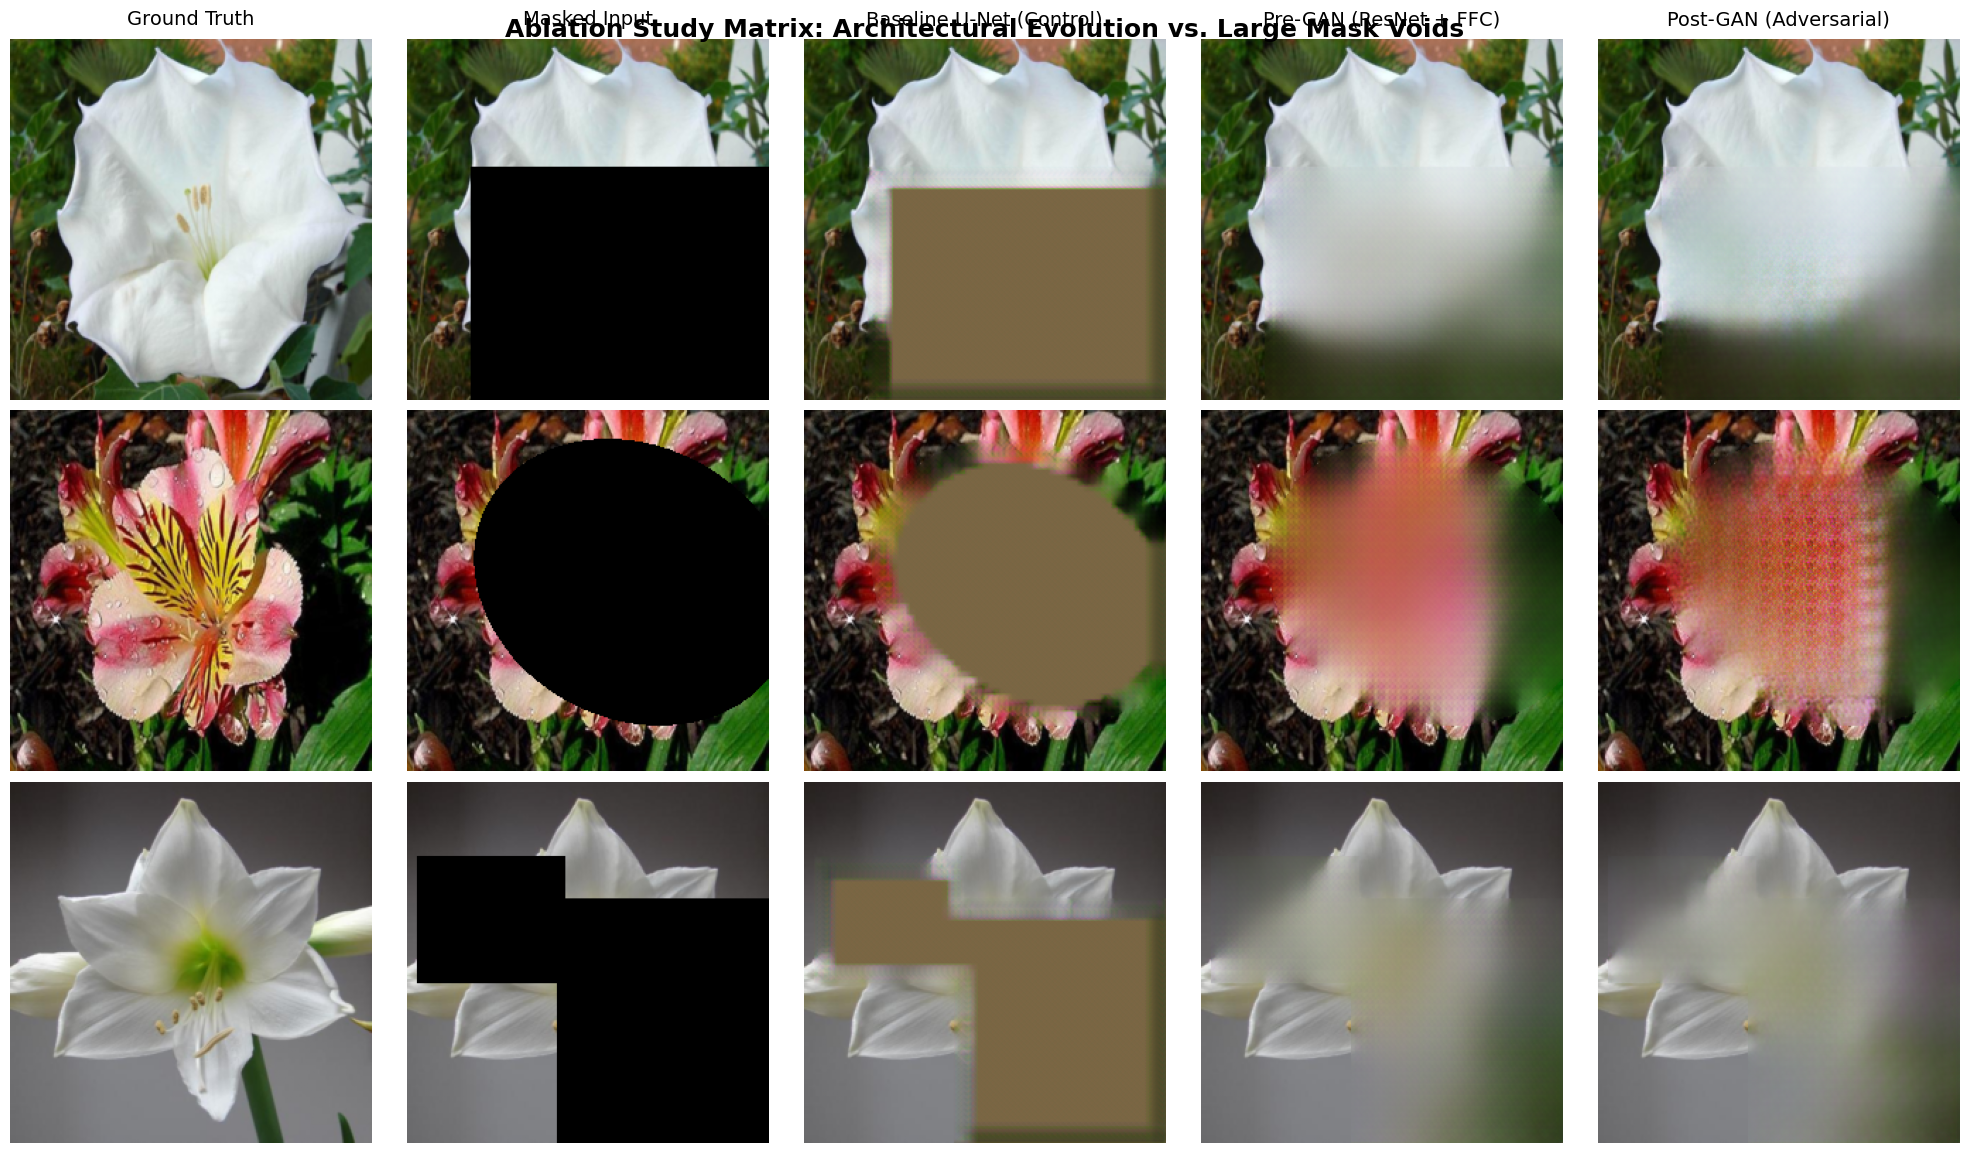


--- Extracting Quantitative Metrics on Unseen Test Split ---
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


Scoring Post-GAN Master: 100%|██████████| 154/154 [00:18<00:00,  8.36it/s]


✅ COMPREHENSIVE EVALUATION MATRIX (UNSEEN TEST SPLIT)
| Architecture | PSNR ↑ | SSIM ↑ | LPIPS ↓ |
| :--- | :--- | :--- | :--- |
| Baseline U-Net (Control) | 17.04 | 0.7157 | 0.2806 |
| Pre-GAN (ResNet + FFC)   | 18.90 | 0.7608 | 0.2518 |
| Post-GAN (Adversarial)   | 18.80 | 0.7567 | 0.2451 |


In [9]:
# ==========================================================
# EXECUTE STAGE 7: Final Evaluation & Comprehensive Visual Proof
# ==========================================================
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

# Import architectures for comparative evaluation
from models.unet_gated import BaselineUNet
from models.bigLaMa import BigLaMa

# Ensure evaluation metric libraries are installed
!pip install -q lpips torchmetrics
import lpips
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

print("Initializing Phase 7: Comprehensive Ablation Evaluation & Metric Extraction...\n")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Fetch the Unseen Test Data (15% holdout split)
test_loader_visual = get_test_loader(batch_size=3)
test_loader_metrics = get_test_loader(batch_size=8)

# 2. Load all three architectural checkpoints into VRAM
print("Loading architectural checkpoints into VRAM...")

model_base = BaselineUNet().to(device)
model_base.load_state_dict(torch.load("models/saved_weights/BaseLine_UNet_Master.pth", map_location=device, weights_only=True))
model_base.eval()

model_pre_gan = BigLaMa().to(device)
model_pre_gan.load_state_dict(torch.load("models/saved_weights/ResNetLama_Master.pth", map_location=device, weights_only=True))
model_pre_gan.eval()

model_post_gan = BigLaMa().to(device)
model_post_gan.load_state_dict(torch.load("models/saved_weights/GAN_Generator_Final.pth", map_location=device, weights_only=True))
model_post_gan.eval()

# ==========================================================
# PART A: VISUAL PROOF (5-COLUMN ABLATION MATRIX)
# ==========================================================
print("\n--- Generating Comprehensive Visual Proof Matrix ---")
batch = next(iter(test_loader_visual))
gt_images = batch["ground_truth"].to(device)
masked_images = batch["masked_image"].to(device)
masks = batch["mask"].to(device)

# Execute Pure FP32 inference across all models simultaneously
with torch.no_grad():
    base_outputs = model_base(masked_images, masks)
    pre_gan_outputs = model_pre_gan(masked_images, masks)
    post_gan_outputs = model_post_gan(masked_images, masks)

def denorm(tensor):
    return (tensor + 1.0) / 2.0

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("Ablation Study Matrix: Architectural Evolution vs. Large Mask Voids", fontsize=18, fontweight='bold', y=0.95)
titles = ["Ground Truth", "Masked Input", "Baseline U-Net (Control)", "Pre-GAN (ResNet + FFC)", "Post-GAN (Adversarial)"]

for i in range(3):
    gt = denorm(gt_images[i]).cpu().permute(1, 2, 0).clamp(0, 1)
    mask_layer = masks[i].cpu().permute(1, 2, 0)
    masked_in = gt * (1 - mask_layer)

    # Composite generated outputs strictly within the mask voids
    raw_base = denorm(base_outputs[i]).cpu().permute(1, 2, 0).clamp(0, 1)
    comp_base = (gt * (1 - mask_layer)) + (raw_base * mask_layer)

    raw_pre = denorm(pre_gan_outputs[i]).cpu().permute(1, 2, 0).clamp(0, 1)
    comp_pre = (gt * (1 - mask_layer)) + (raw_pre * mask_layer)

    raw_post = denorm(post_gan_outputs[i]).cpu().permute(1, 2, 0).clamp(0, 1)
    comp_post = (gt * (1 - mask_layer)) + (raw_post * mask_layer)

    row_images = [gt, masked_in, comp_base, comp_pre, comp_post]

    for j, img in enumerate(row_images):
        axes[i, j].imshow(img.numpy())
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=14, pad=10)

plt.tight_layout()
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/Final_Visual_Comparison_Full.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================================
# PART B: QUANTITATIVE METRICS EXTRACTION
# ==========================================================
print("\n--- Extracting Quantitative Metrics on Unseen Test Split ---")
psnr_metric = PeakSignalNoiseRatio(data_range=2.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
lpips_metric = lpips.LPIPS(net='vgg').to(device)

def score_model(model, name):
    t_psnr, t_ssim, t_lpips, batches = 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for b in tqdm(test_loader_metrics, desc=f"Scoring {name}"):
            gt, masked, mask = b["ground_truth"].to(device), b["masked_image"].to(device), b["mask"].to(device)

            # Pure FP32 inference for evaluation
            out = model(masked, mask)

            # Composite before calculating evaluation metrics
            comp = (gt * (1 - mask)) + (out * mask)

            t_psnr += psnr_metric(comp, gt).item()
            t_ssim += ssim_metric(comp, gt).item()
            t_lpips += lpips_metric(comp, gt).mean().item()
            batches += 1

    return t_psnr / batches, t_ssim / batches, t_lpips / batches

base_scores = score_model(model_base, "Baseline U-Net")
pre_scores = score_model(model_pre_gan, "Pre-GAN Master")
post_scores = score_model(model_post_gan, "Post-GAN Master")

print("\n========================================================================")
print("✅ COMPREHENSIVE EVALUATION MATRIX (UNSEEN TEST SPLIT)")
print("========================================================================")
print("| Architecture | PSNR ↑ | SSIM ↑ | LPIPS ↓ |")
print("| :--- | :--- | :--- | :--- |")
print(f"| Baseline U-Net (Control) | {base_scores[0]:.2f} | {base_scores[1]:.4f} | {base_scores[2]:.4f} |")
print(f"| Pre-GAN (ResNet + FFC)   | {pre_scores[0]:.2f} | {pre_scores[1]:.4f} | {pre_scores[2]:.4f} |")
print(f"| Post-GAN (Adversarial)   | {post_scores[0]:.2f} | {post_scores[1]:.4f} | {post_scores[2]:.4f} |")

## Pipeline Stage 8: Interactive Inference & Deployment

This final stage transitions the codebase from an experimental training environment into a deployable, interactive research tool. We utilize Gradio to instantiate a local UI that allows for real-time visual inspection of the adversarial network's hallucinatory capabilities.

**Technical Execution & Logic Breakdown:**
1. **Mathematical Inference Wrapper:** The `inpaint_image` function encapsulates the strict FP32 precision requirements and exact normalization order (`[0, 1]` -> `[-1, 1]` -> `Apply Mask`) established during training, ensuring the UI does not trigger mathematical overflow (NaN) errors.
2. **Procedural Mask Generation:** Instead of relying on static user input, the pipeline programmatically generates randomized geometric masks (ellipses, rectangles, lines) on the fly. This serves as an interactive proof that the network is truly generalizing to Out-of-Distribution (OOD) structural voids rather than memorizing specific training masks.
3. **Session Management:** Incorporates dynamic memory and port management (`gr.close_all()`) to ensure computational stability across multiple interactive executions within the hosted runtime.

In [ ]:
# ==========================================================
# EXECUTE STAGE 8: Custom Automated Gradio Pipeline
# ==========================================================
import os
import torch
import random
import numpy as np
from PIL import Image, ImageDraw

import gradio as gr
from models.bigLaMa import BigLaMa

# Prevent Colab port hanging on multiple executions
gr.close_all()

print("Initializing Phase 8: Spinning up Custom Inference App...\n")

# 1. Initialize Device and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = BigLaMa().to(device)

weights_path = "models/saved_weights/GAN_Generator_Final.pth"
if os.path.exists(weights_path):
    final_model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    final_model.eval()
    print("✅ Final GAN weights loaded successfully.")
else:
    raise FileNotFoundError(f"❌ Weights not found at {weights_path}.")

# 2. Custom Random Mask Generator
def generate_random_mask(img):
    if img is None:
        return None, None

    img_resized = img.resize((256, 256), Image.LANCZOS)

    # Create a blank binary mask (0 = keep pixel, 1 = drop pixel)
    mask = Image.new("L", (256, 256), 0)
    draw = ImageDraw.Draw(mask)

    # Procedurally draw 1 to 4 random geometric shapes
    for _ in range(random.randint(1, 4)):
        shape_type = random.choice(["ellipse", "rectangle", "line"])
        x1 = random.randint(0, 200)
        y1 = random.randint(0, 200)
        x2 = x1 + random.randint(40, 120)
        y2 = y1 + random.randint(40, 120)

        if shape_type == "ellipse":
            draw.ellipse([x1, y1, x2, y2], fill=255)
        elif shape_type == "rectangle":
            draw.rectangle([x1, y1, x2, y2], fill=255)
        else:
            draw.line([x1, y1, x2, y2], fill=255, width=random.randint(15, 40))

    # Create a visual preview: black out the masked areas on the image
    img_np = np.array(img_resized)
    mask_np = np.array(mask) / 255.0

    preview_np = img_np * (1.0 - np.expand_dims(mask_np, axis=-1))
    preview_img = Image.fromarray(preview_np.astype(np.uint8))

    # Return the preview to the UI, and the raw mask to the hidden state
    return preview_img, mask

# 3. The Mathematically Correct Inference Wrapper
def inpaint_image(original_img, mask):
    if original_img is None or mask is None:
        return None

    img_resized = original_img.resize((256, 256), Image.LANCZOS)

    # Convert to [0, 1] arrays
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    mask_np = np.array(mask).astype(np.float32) / 255.0
    mask_expanded = np.expand_dims(mask_np, axis=-1)

    # ---> THE FIX: CORRECT NORMALIZATION ORDER <---
    # 1. Normalize the pristine image to [-1, 1] FIRST
    img_normalized = (img_np * 2.0) - 1.0

    # 2. THEN mathematically erase the pixels (holes become exactly 0.0)
    masked_img_normalized = img_normalized * (1.0 - mask_expanded)

    # Convert to Tensors: [1, C, H, W]
    img_tensor = torch.from_numpy(masked_img_normalized).permute(2, 0, 1).unsqueeze(0).to(device)
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).to(device)

    # Execute Pure FP32 Inference
    with torch.no_grad():
        generated_out = final_model(img_tensor, mask_tensor)

    # --- POST-PROCESSING ---
    gen_denorm = (generated_out.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1.0) / 2.0
    gen_denorm = np.clip(gen_denorm, 0, 1)

    # Composite the hallucination back into the original image
    final_composite = (img_np * (1.0 - mask_expanded)) + (gen_denorm * mask_expanded)

    return Image.fromarray((final_composite * 255).astype(np.uint8))

# 4. Construct the Custom UI Layout
with gr.Blocks() as demo:
    gr.Markdown("### 🌸 Paint-Paint: Domain-Adaptive Flower Inpainting")

    # A hidden state variable to pass the generated mask between buttons
    hidden_mask = gr.State()

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="1. Upload Original Image")
            btn_mask = gr.Button("2. Apply Random Mask", variant="secondary")

        with gr.Column():
            preview_image = gr.Image(type="pil", label="3. Masked Preview", interactive=False)
            btn_inpaint = gr.Button("4. Run BigLaMa Inpainting", variant="primary")

        with gr.Column():
            output_image = gr.Image(type="pil", label="5. AI Restored Output", interactive=False)

    # Button Actions
    btn_mask.click(fn=generate_random_mask, inputs=input_image, outputs=[preview_image, hidden_mask])
    btn_inpaint.click(fn=inpaint_image, inputs=[input_image, hidden_mask], outputs=output_image)

demo.launch(theme=gr.themes.Soft(), share=True, debug=True)